# Lab 8: Designing and Training a Custom CNN

**Course:** Machine Learning Lab  
**Topic:** Convolutional Neural Network for image classification

## Lab Objective
The objective of this lab is to design, train, and evaluate a custom CNN model for classifying images from the dataset prepared in Lab 7.

# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

1. Import Required Libraries

These imports provide Keras layers, model-building tools, optimizers, image data loading utilities, callbacks, plotting functions, and evaluation metrics.
2. Set Checkpoint Location

The checkpoint path defines where the best model weights will be saved during training based on validation loss.


In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

# 2. Set Checkpoint Location

The checkpoint path defines where the best model weights will be saved during training based on validation loss.


In [2]:
checkpoints = r'F:\university files\8th semester\machine learning lab\datasets\basedata\practice\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

# 3. Define Dataset Directories

The train, validation, and test directories point to the organized image dataset created earlier. These paths are used by ImageDataGenerator to load images by class folder.

In [3]:
train_dir = r'F:\university files\8th semester\machine learning lab\datasets\basedata\practice\train'
validation_dir = r'F:\university files\8th semester\machine learning lab\datasets\basedata\practice\validation'
test_dir = r'F:\university files\8th semester\machine learning lab\datasets\basedata\practice\test'

# 4. Build the CNN Architecture

The model uses convolution and pooling layers to extract image features, followed by dense layers for classification. The final softmax layer predicts the image class.m
                                                                                                  

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(3,activation='softmax'))

# 5. Display Model Summary

The summary shows the output shape and number of trainable parameters for each layer, which helps verify the CNN structure.

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)       0

# 6. Compile the Model

The model is compiled using categorical crossentropy for multi-class classification, RMSprop as the optimizer, and accuracy as the evaluation metric.

In [6]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4), metrics=['acc'])

# 7. Load and Rescale Image Data

ImageDataGenerator rescales pixel values from 0-255 to 0-1 and loads images from the class folders in batches.

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 300 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


# 8. Configure Model Checkpoint¶

The checkpoint callback saves the best model during training so the model with the lowest validation loss can be reused later

In [8]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

# 9. Train the CNN

The model is trained using batches from the training generator and evaluated on the validation generator after each epoch.

In [9]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=2,
                    callbacks=callbacks)

Epoch 1/2



9/9 [==============================] - ETA: 0s - loss: 1.4154 - acc: 0.3246
Epoch 1: val_loss improved from inf to 1.09770, saving model to F:\university files\8th semester\machine learning lab\datasets\basedata\practice\E1-cp-0001-loss1.10.h5
9/9 [==============================] - 22s 2s/step - loss: 1.4154 - acc: 0.3246 - val_loss: 1.0977 - val_acc: 0.4000
Epoch 2/2


F:\university files\8th semester\machine learning lab\myenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


9/9 [==============================] - ETA: 0s - loss: 1.0973 - acc: 0.3694
Epoch 2: val_loss improved from 1.09770 to 1.09119, saving model to F:\university files\8th semester\machine learning lab\datasets\basedata\practice\E1-cp-0002-loss1.09.h5
9/9 [==============================] - 14s 2s/step - loss: 1.0973 - acc: 0.3694 - val_loss: 1.0912 - val_acc: 0.3333


# 10. Inspect Training History

The history dictionary stores accuracy and loss values for each epoch. These values are used to understand training progress.

In [10]:
model_history.history

{'loss': [1.4154289960861206, 1.0972636938095093],
 'acc': [0.3246268630027771, 0.3694029748439789],
 'val_loss': [1.097703456878662, 1.0911880731582642],
 'val_acc': [0.4000000059604645, 0.3333333432674408]}

# 11. Plot Accuracy and Loss

The plots compare training and validation performance. A large gap between training and validation curves may indicate overfitting.

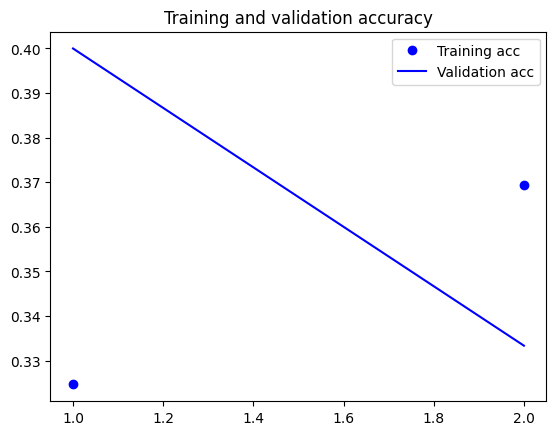

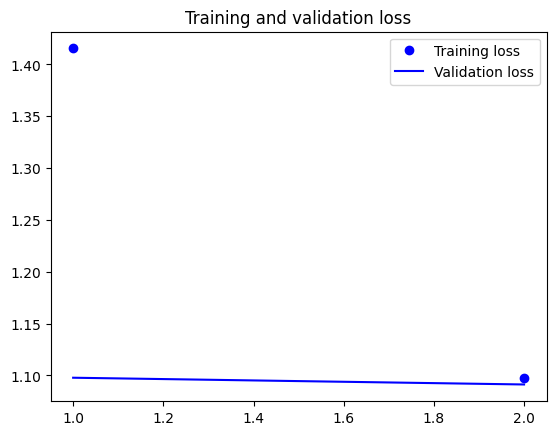

<Figure size 640x480 with 0 Axes>

In [11]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'F:\university files\8th semester\machine learning lab\datasets\basedata\practice\model_Accuracy.png')

# 12. Save the Trained Model

Saving the model allows it to be loaded later without retraining.

In [12]:
model.save(r'F:\university files\8th semester\machine learning lab\datasets\basedata\practice\E1-cp-0012-loss0.21.h5')

# 13. Evaluate on Test Data

The test generator loads unseen test images. Predictions are compared with true labels to measure final classification performance.

Found 30 images belonging to 3 classes.
1/1 [==============================] - 1s 639ms/step


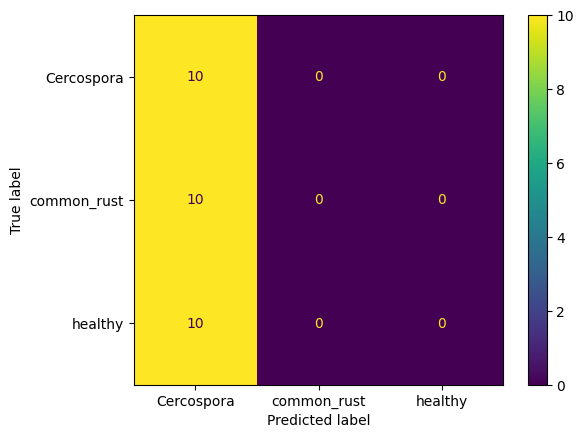

In [13]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

# 14. Classification Report

The classification report shows precision, recall, F1-score, and support for each class, giving a clearer evaluation than accuracy alone.m

In [14]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy']))

              precision    recall  f1-score   support

  Cercospora       0.33      1.00      0.50        10
 common_rust       0.00      0.00      0.00        10
     healthy       0.00      0.00      0.00        10

    accuracy                           0.33        30
   macro avg       0.11      0.33      0.17        30
weighted avg       0.11      0.33      0.17        30



F:\university files\8th semester\machine learning lab\myenv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
F:\university files\8th semester\machine learning lab\myenv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
F:\university files\8th semester\machine learning lab\myenv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

# Conclusion

This lab demonstrates the complete CNN workflow: defining the architecture, loading image data, training the model, saving checkpoints, plotting performance, and evaluating the model on test images.